In [2]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------

In [1]:
import pandas as pd

# Load dataset (change path accordingly)
df = pd.read_excel("100k_filtered_raw_bug_reports.xlsx")

# Basic check
print(df.head())
print(df.info())

                 author         creation_time   bug_id  \
0   itiel_yn8@walla.com  2022-11-19T21:20:37Z  1801502   
1   itiel_yn8@walla.com  2022-11-19T21:20:37Z  1801502   
2    0xgodson@gmail.com  2022-11-19T21:02:27Z  1801501   
3      emilio@crisal.io  2022-11-19T20:58:00Z  1801500   
4  wptsync@mozilla.bugs  2022-11-19T20:48:45Z  1801498   

                                                text  Bug report  author_id  \
0  created attachment 9304261screenshotthis is es...        True   353822.0   
1  created attachment 9304261screenshotthis is es...        True   353822.0   
2  created attachment 9304259index.htmlbrowser us...        True   713322.0   
3                             as per comments there.        True   546716.0   
4  sync web-platform-tests pr 37041 into mozilla-...        True   611017.0   

     status resolution  contains_steps_to_reproduce  
0  VERIFIED      FIXED                        False  
1  VERIFIED      FIXED                        False  
2  RESOLVED   

In [3]:
df.duplicated().sum()

np.int64(36034)

In [5]:
# Convert time
df['creation_time'] = pd.to_datetime(df['creation_time'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['creation_time', 'bug_id'])

# Remove duplicates
df = df.drop_duplicates(subset=['bug_id'])

print("Cleaned shape:", df.shape)

Cleaned shape: (83550, 9)


In [7]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 11.0 MB/s  0:00:00
Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsin

resolution
FIXED    83550
Name: count, dtype: int64


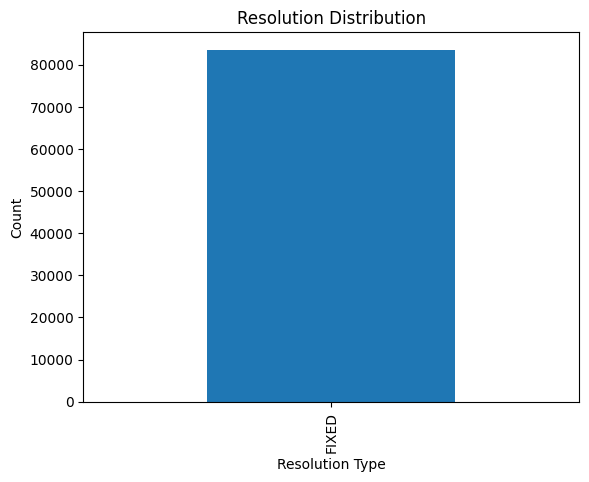

In [8]:
import matplotlib.pyplot as plt

resolution_counts = df['resolution'].value_counts()
print(resolution_counts)

resolution_counts.plot(kind='bar')
plt.title("Resolution Distribution")
plt.xlabel("Resolution Type")
plt.ylabel("Count")
plt.show()

status
RESOLVED    74850
VERIFIED     8700
Name: count, dtype: int64


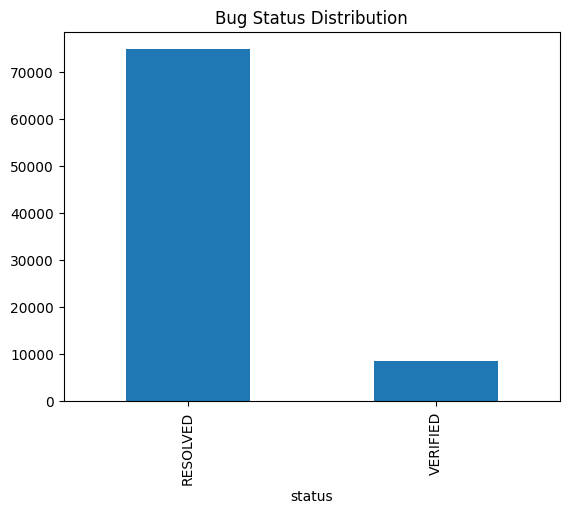

In [9]:
status_counts = df['status'].value_counts()
print(status_counts)

status_counts.plot(kind='bar')
plt.title("Bug Status Distribution")
plt.show()

In [10]:
cross_tab = pd.crosstab(df['status'], df['resolution'])
print(cross_tab)

resolution  FIXED
status           
RESOLVED    74850
VERIFIED     8700


author
wptsync@mozilla.bugs                   12784
intermittent-bug-filer@mozilla.bugs     3709
mh+mozilla@glandium.org                 1296
emilio@crisal.io                        1233
standard8@mozilla.com                    867
nchevobbe@mozilla.com                    763
aryx.bugmail@gmx-topmail.de              762
twsmith@mozilla.com                      625
hskupin@gmail.com                        606
willkg@mozilla.com                       582
Name: count, dtype: int64


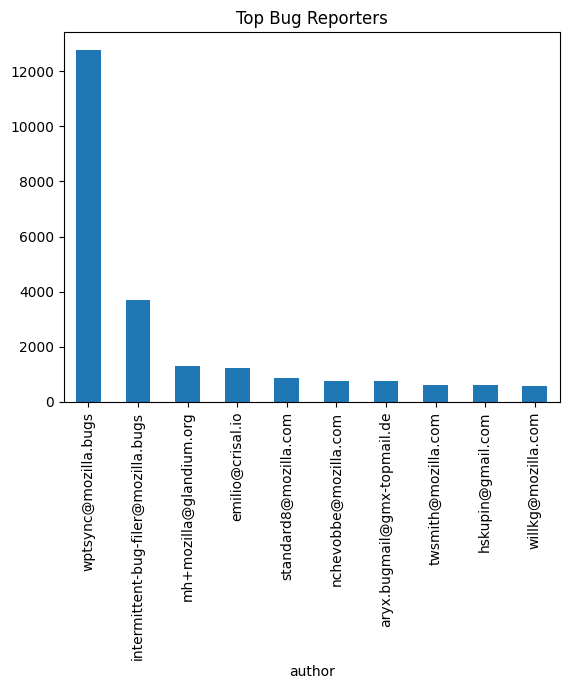

In [11]:
top_authors = df['author'].value_counts().head(10)
print(top_authors)

top_authors.plot(kind='bar')
plt.title("Top Bug Reporters")
plt.show()

In [12]:
top_dev_ids = df['author_id'].value_counts().head(10)
print(top_dev_ids)

author_id
611017.0    12783
573381.0     3707
47192.0      1296
546716.0     1233
112088.0      867
557153.0      763
258347.0      762
486634.0      625
76551.0       606
424160.0      582
Name: count, dtype: int64


In [13]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Use text column
texts = df['text'].fillna("")

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(texts)

# Compute similarity (sample to avoid memory issue)
sample_X = X[:1000]
similarity_matrix = cosine_similarity(sample_X)

In [15]:
!pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)


In [16]:
import networkx as nx

G = nx.Graph()

sample_df = df.iloc[:1000]

for i in range(len(sample_df)):
    for j in range(i+1, len(sample_df)):
        if similarity_matrix[i][j] > 0.7:
            a1 = sample_df.iloc[i]['author']
            a2 = sample_df.iloc[j]['author']
            
            if a1 != a2:
                G.add_edge(a1, a2)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 17
Edges: 10


contains_steps_to_reproduce
False    75028
True      8522
Name: count, dtype: int64


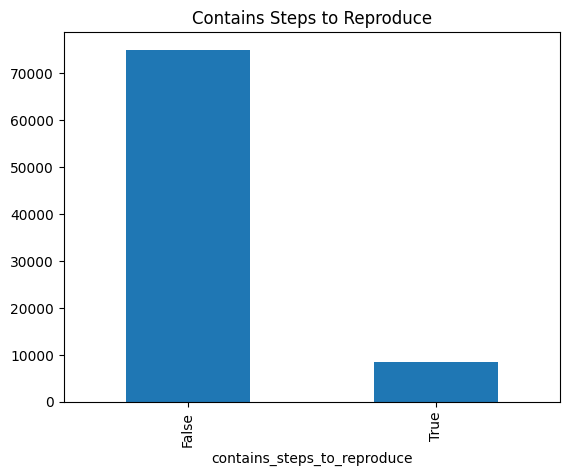

In [17]:
steps_counts = df['contains_steps_to_reproduce'].value_counts()
print(steps_counts)

steps_counts.plot(kind='bar')
plt.title("Contains Steps to Reproduce")
plt.show()

In [18]:
repro_vs_res = pd.crosstab(df['contains_steps_to_reproduce'], df['resolution'])
print(repro_vs_res)

resolution                   FIXED
contains_steps_to_reproduce       
False                        75028
True                          8522


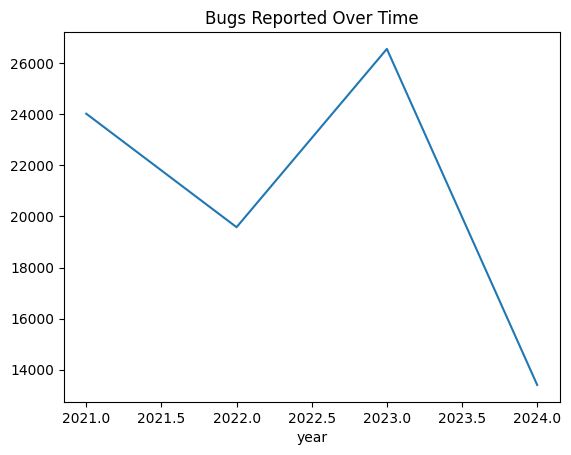

In [19]:
df['year'] = df['creation_time'].dt.year

yearly = df.groupby('year').size()
yearly.plot()
plt.title("Bugs Reported Over Time")
plt.show()

C:\Users\kundu\AppData\Local\Temp\ipykernel_43904\3327141594.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['creation_time'].dt.to_period('M')


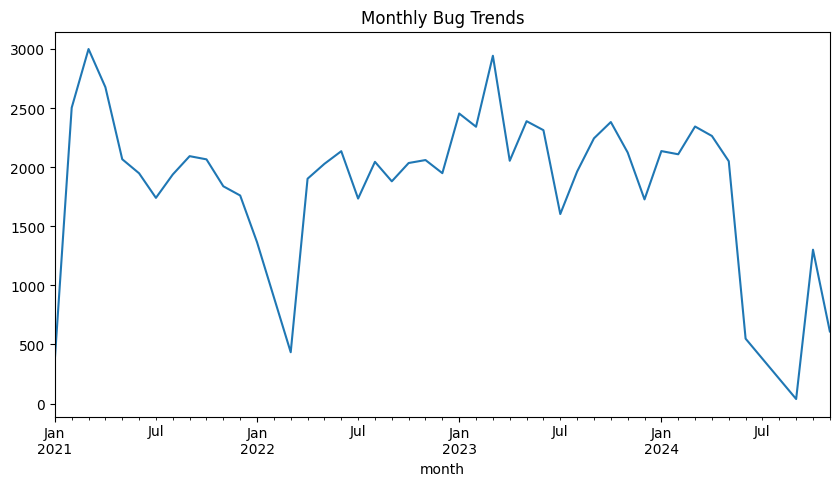

In [20]:
df['month'] = df['creation_time'].dt.to_period('M')

monthly = df.groupby('month').size()
monthly.plot(figsize=(10,5))
plt.title("Monthly Bug Trends")
plt.show()

In [21]:
from collections import Counter
import re

all_text = " ".join(df['text'].dropna())

words = re.findall(r'\w+', all_text.lower())
common_words = Counter(words).most_common(20)

print(common_words)

[('the', 290491), ('task', 220123), ('info', 198748), ('mozilla', 184821), ('to', 166469), ('in', 166162), ('js', 109392), ('a', 109132), ('is', 108114), ('https', 103953), ('gecko', 91379), ('this', 84941), ('0', 84490), ('cpp', 82898), ('worker', 82307), ('builds', 80447), ('and', 79996), ('com', 74913), ('test', 72955), ('of', 70069)]


Nodes (Authors): 6
Edges (Collaborations): 3


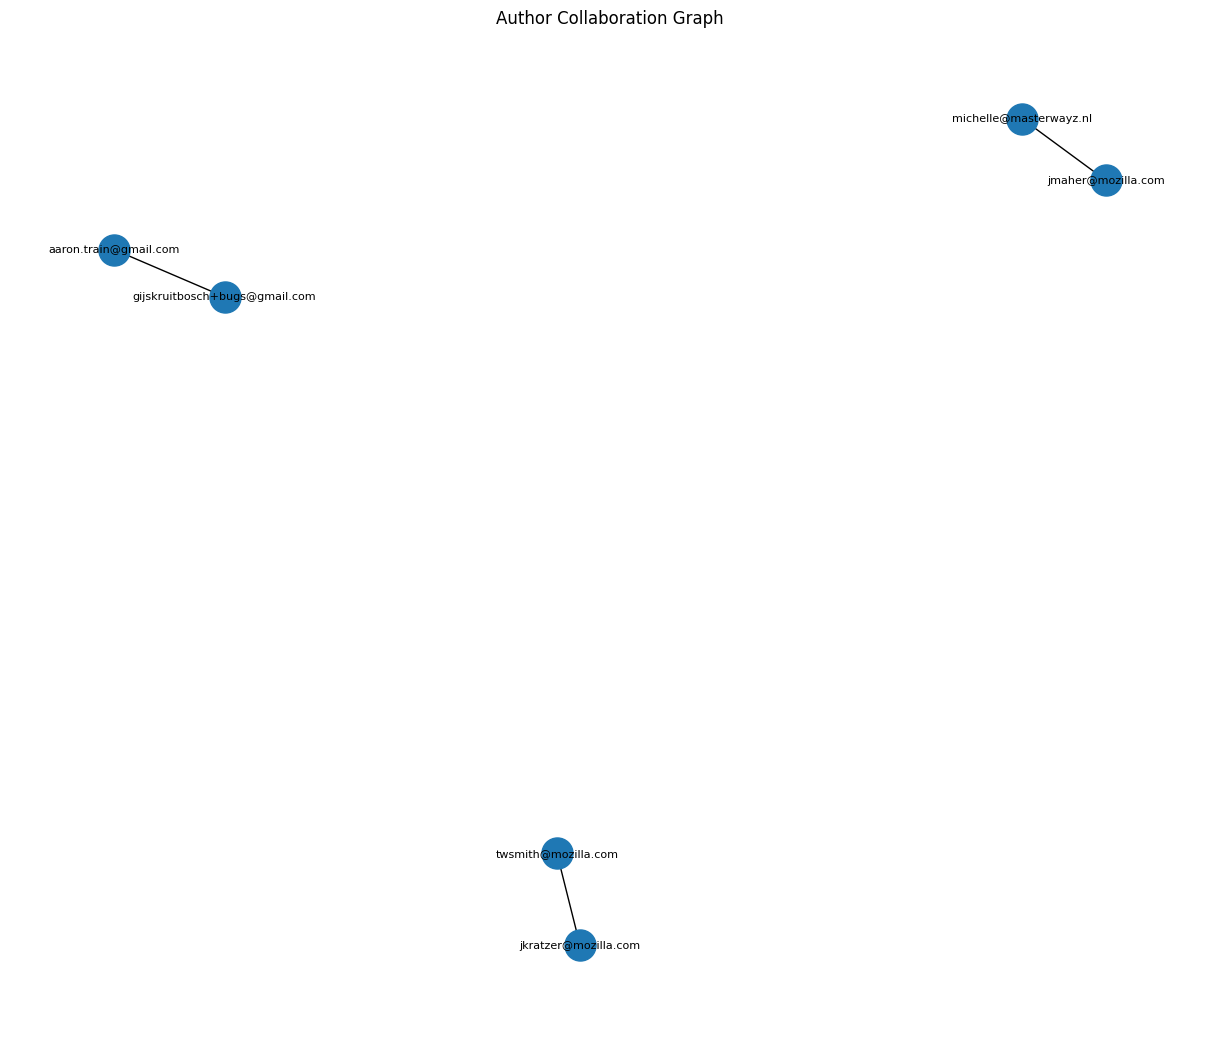

In [23]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# Step 1: Load dataset
# -------------------------------
df = pd.read_excel("100k_filtered_raw_bug_reports.xlsx")

# Clean data
df = df.dropna(subset=['author', 'text'])

# -------------------------------
# Step 2: Reduce dataset (IMPORTANT for performance)
# -------------------------------
df_sample = df.sample(500, random_state=42)  # use 500–1000 max

texts = df_sample['text']

# -------------------------------
# Step 3: Convert text → TF-IDF
# -------------------------------
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(texts)

# -------------------------------
# Step 4: Compute similarity
# -------------------------------
similarity_matrix = cosine_similarity(X)

# -------------------------------
# Step 5: Build Graph
# -------------------------------
G = nx.Graph()

authors = df_sample['author'].tolist()

for i in range(len(authors)):
    for j in range(i + 1, len(authors)):
        if similarity_matrix[i][j] > 0.7:   # threshold
            a1 = authors[i]
            a2 = authors[j]

            if a1 != a2:
                G.add_edge(a1, a2)

print("Nodes (Authors):", G.number_of_nodes())
print("Edges (Collaborations):", G.number_of_edges())

# -------------------------------
# Step 6: Draw Graph
# -------------------------------
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=500,
    font_size=8
)

plt.title("Author Collaboration Graph")
plt.show()

In [24]:
df.sample(500)

,author,creation_time,bug_id,text,Bug report,author_id,status,resolution,contains_steps_to_reproduce
114796,wptsync@mozilla.bugs,2023-01-27T19:56:29Z,1813158,sync web-platform-tests pr 38226 into mozilla-...,True,611017.0,RESOLVED,FIXED,False
65800,gsvelto@mozilla.com,2021-04-12T16:18:36Z,1704561,crash report: https://crash-stats.mozilla.org/...,True,448747.0,RESOLVED,FIXED,False
41261,agi@sferro.dev,2021-06-25T21:44:49Z,1718341,right now the android emulator is stored in a ...,True,421286.0,RESOLVED,FIXED,False
41095,wptsync@mozilla.bugs,2021-06-28T07:33:36Z,1718504,sync web-platform-tests pr 29516 into mozilla-...,True,611017.0,RESOLVED,FIXED,False
8568,intermittent-bug-filer@mozilla.bugs,2021-02-08T22:21:48Z,1691557,**filed by:** nbeleuzu [at] mozilla.com**parse...,True,573381.0,RESOLVED,FIXED,False
...,...,...,...,...,...,...,...,...,...
37212,edilee@mozilla.com,2021-09-24T15:27:54Z,1732471,we'll most likely need to set a pref. ~unclear...,True,125983.0,RESOLVED,FIXED,False
112340,richard.marti@gmail.com,2023-02-25T10:12:27Z,1818878,with the support of media queries for high con...,True,282357.0,RESOLVED,FIXED,False
11140,neclimdul@gmail.com,2021-01-29T14:32:17Z,1689622,user agent: mozilla/5.0 (x11; linux x86_64) ap...,True,222036.0,RESOLVED,FIXED,True
59148,sfoster@mozilla.com,2021-04-29T21:50:18Z,1708558,created attachment 9219372image(1).pngwe have ...,True,430165.0,VERIFIED,FIXED,False


In [25]:
top_authors = df['author'].value_counts().head(20).index
df_sample = df[df['author'].isin(top_authors)].head(500)

In [27]:
df.shape
df.columns

Index(['author', 'creation_time', 'bug_id', 'text', 'Bug report', 'author_id',
       'status', 'resolution', 'contains_steps_to_reproduce'],
      dtype='str')